# IU X-ray — train, report generation




## 1. Install and mount

In [ ]:
!pip install -q transformers accelerate bitsandbytes peft datasets
!pip install -q nltk rouge-score bert-score f1chexbert radgraph


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 20.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.0/588.0 kB 29.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 1.9 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys, json, time, math, random, hashlib, shutil, subprocess
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt

OUT_ROOT = "/content/drive/MyDrive/MSC_VLM_GROUNDED"
RUN_NAME = "A_iu_unified"
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

Mounted at /content/drive
device: cuda


## 2. Definitions

Identical to the PadChest run. Coordinate tokens are added but never emitted
here — keeping the vocabulary the same is what makes "same architecture"
literally true.

In [ ]:
import re

class CFG:
    SEED = 42

    # vision
    IMG_SIZE = 518
    PATCH = 14
    RAW_GRID = 37                  # 518 / 14
    POOL_GRID = 19
    VISION_DIM = 768

    # coordinate vocabulary
    COORD_BINS = 32                # -> 64 tokens (32 x + 32 y)

    # llm
    LLM_ID = "Qwen/Qwen2.5-3B-Instruct"
    LORA_R = 32
    LORA_ALPHA = 64
    LORA_DROPOUT = 0.05
    LORA_TARGETS = ["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"]

    # training —
    EPOCHS = 1                     # checkpoints every 300 steps
    BATCH = 1
    ACCUM = 8                     # effective batch 16
    LR = 2e-6
    LR_ADAPTER = 5e-5
    WARMUP_FRAC = 0.03
    MAX_LEN = 512
    GROUNDED_FRACTION = 1.0        # abnormal-only run: every sample grounded
    # decoding
    MAX_NEW_TOKENS = 220
    DO_SAMPLE = True               # greedy under-produces boxes
    TOP_P = 0.9
    TEMPERATURE = 0.7


def seed_everything(s=CFG.SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)


# ==============================================================================
# PROMPTS
# ==============================================================================

SYSTEM = ("<|im_start|>system\nYou are an expert radiology assistant tasked "
          "with interpreting a chest X-ray study.<|im_end|>\n")

INSTR_FINDGEN = (
    "<|im_start|>user\nProvide a description of the findings in the radiology "
    "study. Each finding should be described as a self-contained plain-text "
    "sentence.<|im_end|>\n<|im_start|>assistant\n")

INSTR_GROUNDREP = (
    "<|im_start|>user\nProvide a description of the findings in the radiology "
    "study. Each finding should be described as a self-contained plain-text "
    "sentence. If the finding is groundable, locate it in the image with "
    "bounding boxes indicating all locations where it can be seen. Otherwise "
    "generate just the ungrounded finding.<|im_end|>\n<|im_start|>assistant\n")


# ==============================================================================
# COORDINATE VOCABULARY
# ==============================================================================

OBJ_OPEN, OBJ_CLOSE = "<obj>", "</obj>"
BOX_OPEN, BOX_CLOSE = "<box>", "</box>"


def coord_tokens(n=CFG.COORD_BINS):
    return ([f"<x{i}>" for i in range(n)] + [f"<y{i}>" for i in range(n)]
            + [OBJ_OPEN, OBJ_CLOSE, BOX_OPEN, BOX_CLOSE])


def add_coord_tokens(tokenizer, model, n=CFG.COORD_BINS):

    new = coord_tokens(n)
    added = tokenizer.add_tokens(new, special_tokens=True)
    if added == 0:
        return tokenizer, model
    model.resize_token_embeddings(len(tokenizer))
    with torch.no_grad():
        emb = model.get_input_embeddings().weight
        old = emb[:-added].float()
        mu, sd = old.mean(0, keepdim=True), old.std(0, keepdim=True)
        emb[-added:] = (mu + torch.randn(added, emb.shape[1],
                                         device=emb.device) * sd).to(emb.dtype)
        out = model.get_output_embeddings()
        if out is not None and out.weight.data_ptr() != emb.data_ptr():
            o = out.weight[:-added].float()
            om, os_ = o.mean(0, keepdim=True), o.std(0, keepdim=True)
            out.weight[-added:] = (om + torch.randn(added, o.shape[1],
                                                    device=o.device) * os_
                                   ).to(out.weight.dtype)
        chk = emb[-added:]
        spread = chk.float().std(0).mean().item()
    print(f"added {added} tokens | vocab {len(tokenizer)} | "
          f"new-row spread {spread:.5f} (must be > 0)")
    assert spread > 1e-4, "coordinate tokens are identical — init failed"
    return tokenizer, model


def box_to_tokens(box_norm, n=CFG.COORD_BINS):
    """(x0,y0,x1,y1) normalised to [0,1] -> '<x><y><x><y>' token string."""
    x0, y0, x1, y1 = box_norm
    q = lambda v: int(np.clip(round(v * (n - 1)), 0, n - 1))
    return f"<x{q(x0)}><y{q(y0)}><x{q(x1)}><y{q(y1)}>"


BOX_RE = re.compile(r"<x(\d+)><y(\d+)><x(\d+)><y(\d+)>")


def parse_generation(text, n=CFG.COORD_BINS):

    out = []
    for chunk in re.findall(r"<obj>(.*?)</obj>", text, flags=re.S):
        boxes = [(int(a)/(n-1), int(b)/(n-1), int(c)/(n-1), int(d)/(n-1))
                 for a, b, c, d in BOX_RE.findall(chunk)]
        sent = re.sub(r"<box>.*?</box>", "", chunk, flags=re.S)
        sent = BOX_RE.sub("", sent).strip()
        if sent:
            out.append((sent, boxes))
    if not out and text.strip():                  # ungrounded fallback
        out = [(text.strip(), [])]
    return out


# ==============================================================================
# GEOMETRY — image and boxes through the identical transform
# ==============================================================================

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], np.float32)


def preprocess(pil_img, boxes_xyxy=None, size=CFG.IMG_SIZE):

    W, H = pil_img.size
    scale = size / min(W, H)
    nw, nh = int(round(W * scale)), int(round(H * scale))
    img = pil_img.convert("RGB").resize((nw, nh), Image.BILINEAR)
    ox, oy = max(0, (nw - size) // 2), max(0, (nh - size) // 2)
    img = img.crop((ox, oy, ox + size, oy + size))

    arr = np.asarray(img, np.float32) / 255.0
    arr = (arr - IMAGENET_MEAN) / IMAGENET_STD
    px = torch.from_numpy(arr).permute(2, 0, 1)

    if boxes_xyxy is None:
        return px, None, img

    out = []
    for b in boxes_xyxy:
        nb = (b[0]*scale - ox, b[1]*scale - oy, b[2]*scale - ox, b[3]*scale - oy)
        cl = (max(0., nb[0]), max(0., nb[1]),
              min(float(size), nb[2]), min(float(size), nb[3]))
        oa = max(1e-6, (nb[2]-nb[0]) * (nb[3]-nb[1]))
        sa = max(0., cl[2]-cl[0]) * max(0., cl[3]-cl[1])
        out.append(tuple(v / size for v in cl) if sa/oa >= 0.30 else None)
    return px, out, img




In [ ]:
# ==============================================================================
# TARGET FORMATTING
# ==============================================================================

def format_findgen(sentences):

    return " ".join(s.strip() for s in sentences if s.strip())


def format_groundrep(sentences, boxes_per_sentence):

    parts = []
    for sent, boxes in zip(sentences, boxes_per_sentence):
        s = sent.strip()
        if not s:
            continue
        valid = [b for b in boxes if b is not None]
        if valid:
            btxt = "".join(BOX_OPEN + box_to_tokens(b) + BOX_CLOSE for b in valid)
            parts.append(f"{OBJ_OPEN}{s}{btxt}{OBJ_CLOSE}")
        else:
            parts.append(f"{OBJ_OPEN}{s}{OBJ_CLOSE}")
    return "".join(parts)


# ==============================================================================
# ABSTENTION — three categories
# ==============================================================================

NEGATION_CUES = ["no ", "not ", "without", "free of", "clear of", "negative for",
                 "absence of", "absent", "unremarkable", "normal limits",
                 "within normal", "no evidence"]
NORMALITY_CUES = ["are clear", "is clear", "is normal", "are normal",
                  "unremarkable", "within normal limits", "no abnormalit",
                  "intact", "well-inflated", "well expanded"]
NON_LOCALISABLE_CUES = ["diffuse", "generalised", "generalized", "widespread",
                        "throughout", "global", "hyperinflat", "hypoinflat",
                        "low lung volumes", "emphysema", "copd", "osteopenia",
                        "deminerali", "scoliosis"]


def is_groundable(sentence):
    s = " " + sentence.lower().strip() + " "
    if any(c in s for c in NEGATION_CUES):        return False
    if any(c in s for c in NORMALITY_CUES):       return False
    if any(c in s for c in NON_LOCALISABLE_CUES): return False
    return True


# ==============================================================================
# SPLITS
# ==============================================================================

def study_key(text):

    return hashlib.md5(re.sub(r"\s+", " ", (text or "").strip().lower())
                       .encode()).hexdigest()


def group_split(keys, frac=(0.8, 0.1, 0.1), seed=CFG.SEED):
    uniq = sorted(set(keys)); random.Random(seed).shuffle(uniq)
    n, a, b = len(uniq), int(len(uniq)*frac[0]), int(len(uniq)*(frac[0]+frac[1]))
    assign = {k: ("train" if i < a else "val" if i < b else "test")
              for i, k in enumerate(uniq)}
    out = {"train": [], "val": [], "test": []}
    for i, k in enumerate(keys):
        out[assign[k]].append(i)
    return out


def symmetry_score(pil_img, size=128):
    """Frontal CXRs are near left-right symmetric; laterals are not."""
    a = np.asarray(pil_img.convert("L").resize((size, size)), np.float32)
    b = a[:, ::-1]
    a = (a - a.mean()) / (a.std() + 1e-8)
    b = (b - b.mean()) / (b.std() + 1e-8)
    return float((a * b).mean())


FRONTAL_THRESHOLD = 0.68

In [ ]:
class SpatialMLPAdapter(nn.Module):


    def __init__(self, vision_dim=CFG.VISION_DIM, llm_dim=2048,
                 raw_grid=CFG.RAW_GRID, pool_grid=CFG.POOL_GRID,
                 target_norm=1.0):
        super().__init__()
        self.raw_grid, self.pool_grid = raw_grid, pool_grid
        self.proj = nn.Linear(vision_dim, llm_dim)
        self.norm = nn.LayerNorm(llm_dim)
        self.scale = nn.Parameter(torch.tensor(target_norm / (llm_dim ** 0.5)))

    def forward(self, rad_out):
        x = rad_out[:, 1:, :]
        B, N, C = x.shape
        assert N == self.raw_grid ** 2, (
            f"expected {self.raw_grid**2} patches, got {N}")
        x = x.transpose(1, 2).reshape(B, C, self.raw_grid, self.raw_grid)
        x = F.adaptive_avg_pool2d(x, (self.pool_grid, self.pool_grid))
        x = x.flatten(2).transpose(1, 2)
        return self.norm(self.proj(x)) * self.scale


seed_everything()
print("adapter class ready")

adapter class ready


### 2.1 Per-task hyperparameters

In [ ]:
CFG.EPOCHS     = 3
CFG.ACCUM      = 8
CFG.LR         = 1e-5


CFG.LR_ADAPTER = 5e-5
CFG.MAX_LEN    = 320

print(f"epochs {CFG.EPOCHS} | ACCUM {CFG.ACCUM} | LoRA LR {CFG.LR} | "
      f"adapter LR {CFG.LR_ADAPTER}")

epochs 3 | ACCUM 8 | LoRA LR 1e-05 | adapter LR 5e-05


## 3. IU X-ray data

`Shrey-1329/cxiu_hf_dataset` is flattened one row per **image**. Frontal and
lateral of one study share the same report string, so a random per-image split
puts the partner image — and its verbatim target — in training. Grouping by
report hash recovers study-level splitting; the cell asserts no leakage.

In [ ]:
from datasets import load_dataset


def symmetry_score(pil_img, size=128):
    """Frontal CXRs are near left-right symmetric; laterals are not."""
    a = np.asarray(pil_img.convert("L").resize((size, size)), np.float32)
    b = a[:, ::-1]
    a = (a - a.mean()) / (a.std() + 1e-8)
    b = (b - b.mean()) / (b.std() + 1e-8)
    return float((a * b).mean())


FRONTAL_THRESHOLD = 0.68
SPLITS = f"{OUT_ROOT}/iu_splits.json"

ds_iu = load_dataset("Shrey-1329/cxiu_hf_dataset", split="train")
print(f"{len(ds_iu)} images | columns {ds_iu.column_names}")

if os.path.exists(SPLITS):
    splits = json.load(open(SPLITS))
    print("loaded cached split")
else:
    print("scoring views and grouping studies...")
    sym, keys = [], []
    for i in range(len(ds_iu)):
        it = ds_iu[i]
        sym.append(symmetry_score(it["image"]))
        keys.append(hashlib.md5(
            " ".join((it.get("text") or "").lower().split()).encode()).hexdigest())
        if i % 500 == 0: print(f"  {i}/{len(ds_iu)}")
    frontal = np.array(sym) >= FRONTAL_THRESHOLD
    print(f"frontal {frontal.sum()} | lateral {(~frontal).sum()} | "
          f"studies {len(set(keys))}")

    idx = np.where(frontal)[0]
    uniq = sorted({keys[i] for i in idx}); random.Random(42).shuffle(uniq)
    a, b = int(len(uniq)*.8), int(len(uniq)*.9)
    assign = {k: ("train" if i < a else "val" if i < b else "test")
              for i, k in enumerate(uniq)}
    splits = {"train": [], "val": [], "test": []}
    for i in idx:
        splits[assign[keys[i]]].append(int(i))
    tr = {keys[i] for i in splits["train"]}
    te = {keys[i] for i in splits["test"]}
    va = {keys[i] for i in splits["val"]}
    assert not (tr & te) and not (tr & va) and not (va & te), "STUDY LEAKAGE"
    json.dump(splits, open(SPLITS, "w"))

print({k: len(v) for k, v in splits.items()}, "| no leakage")

README.md:   0%|          | 0.00/1.87k [00:00<?, ?B/s]

data/train-00000-of-00003-34bea7eff0b2e4(…): reconstructing file:   0%|          |  0.00B /  369MB            

data/train-00000-of-00003-34bea7eff0b2e4(…): downloading bytes:           |  0.00B            

data/train-00001-of-00003-e264f8a8545640(…): reconstructing file:   0%|          |  0.00B /  369MB            

data/train-00001-of-00003-e264f8a8545640(…): downloading bytes:           |  0.00B            

data/train-00002-of-00003-b727c3f3dd3884(…): reconstructing file:   0%|          |  0.00B /  370MB            

data/train-00002-of-00003-b727c3f3dd3884(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/6060 [00:00<?, ? examples/s]

6060 images | columns ['image', 'text']
loaded cached split
{'train': 1964, 'val': 252, 'test': 265} | no leakage


In [ ]:
class IUDataset(Dataset):

    def __init__(self, ds, idx):
        self.ds, self.idx = ds, idx

    def __len__(self): return len(self.idx)

    def __getitem__(self, i):
        it = self.ds[self.idx[i]]
        px, _, _ = preprocess(it["image"])
        report = (it.get("text") or "").strip() or "No acute findings."
        return {"px": px, "target": format_findgen([report]),
                "instr": INSTR_FINDGEN, "objective": "findgen"}


train_ds = IUDataset(ds_iu, splits["train"])
val_ds   = IUDataset(ds_iu, splits["val"])
print(f"train {len(train_ds)} | val {len(val_ds)} | test {len(splits['test'])}")
print("\nexample target:", train_ds[0]["target"][:150])

train 1964 | val 252 | test 265

example target: interstitial markings are diffusely prominent throughout both lungs heart size is normal pulmonary  normal


## 4. Model

In [ ]:
def build_model():
    from transformers import (AutoModel, AutoTokenizer, AutoModelForCausalLM,
                              BitsAndBytesConfig)
    from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

    print("Rad-DINO (frozen)...")
    vision = AutoModel.from_pretrained("microsoft/rad-dino").to(device).eval()
    for p in vision.parameters():
        p.requires_grad = False

    print("Qwen2.5-3B (4-bit) + LoRA...")
    tok = AutoTokenizer.from_pretrained(CFG.LLM_ID)
    tok.pad_token = tok.eos_token
    tok.padding_side = "right"
    bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_use_double_quant=True,
                             bnb_4bit_quant_type="nf4",
                             bnb_4bit_compute_dtype=torch.float16)
    base = AutoModelForCausalLM.from_pretrained(
        CFG.LLM_ID, quantization_config=bnb, device_map={"": 0})


    tok, base = add_coord_tokens(tok, base)
    base = prepare_model_for_kbit_training(base)


    lora = LoraConfig(r=CFG.LORA_R, lora_alpha=CFG.LORA_ALPHA,
                      lora_dropout=CFG.LORA_DROPOUT, bias="none",
                      task_type="CAUSAL_LM", target_modules=CFG.LORA_TARGETS)
    llm = get_peft_model(base, lora)
    llm.config.use_cache = False
    llm.gradient_checkpointing_enable()
    llm.enable_input_require_grads()


    n_new = len(coord_tokens())
    emb = llm.get_input_embeddings()
    emb.weight.requires_grad_(True)
    mask = torch.zeros(emb.weight.shape[0], 1,
                       device=emb.weight.device, dtype=emb.weight.dtype)
    mask[-n_new:] = 1.0
    emb.weight.register_hook(lambda g: g * mask)
    llm._n_new_tokens = n_new

    adapter = SpatialMLPAdapter(llm_dim=llm.config.hidden_size).to(device)

    n_ad = sum(p.numel() for p in adapter.parameters())
    n_lora = sum(p.numel() for n, p in llm.named_parameters()
                 if p.requires_grad and "embed_tokens" not in n)
    n_emb_eff = n_new * emb.weight.shape[1]        # effective, after masking
    n_frozen = sum(p.numel() for p in llm.parameters()) \
        + sum(p.numel() for p in vision.parameters())
    tot = n_ad + n_lora + n_emb_eff
    print(f"\nTRAINABLE PARAMETERS")
    print(f"  MLP adapter          {n_ad:>12,}")
    print(f"  LoRA (r={CFG.LORA_R})           {n_lora:>12,}")
    print(f"  coord embeddings     {n_emb_eff:>12,}  "
          f"({n_new} tokens x {emb.weight.shape[1]})")
    print(f"  ------------------------------------")
    print(f"  total trainable      {tot:>12,}  ({100*tot/max(1,n_frozen):.2f}% "
          f"of the frozen backbone)")
    return vision, tok, llm, adapter

In [ ]:
@torch.no_grad()
def encode_image(vision, px):
    return vision(px.to(device)).last_hidden_state


seed_everything()
vision, tok, llm, adapter = build_model()
assert hasattr(adapter, "scale") and not hasattr(adapter, "mlp"), "WRONG ADAPTER"

new = llm.get_input_embeddings().weight[-68:]
print(f"\ncoord-token spread {new.float().std(0).mean().item():.5f} (must be >0)")
assert new.float().std(0).mean().item() > 1e-4

Rad-DINO (frozen)...


config.json:   0%|          | 0.00/879 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

added 68 tokens | vocab 151733 | new-row spread 0.02339 (must be > 0)

TRAINABLE PARAMETERS
  MLP adapter             1,579,009
  LoRA (r=32)             59,867,136
  coord embeddings          139,264  (68 tokens x 2048)
  ------------------------------------
  total trainable        61,585,409  (3.34% of the frozen backbone)

coord-token spread 0.02339 (must be >0)


### 4.1 Collation and loss

In [ ]:
def make_collate(tok):
    def collate(batch):
        px = torch.stack([b["px"] for b in batch])
        prompts = [SYSTEM + b["instr"] for b in batch]
        fulls = [p + b["target"] + tok.eos_token for p, b in zip(prompts, batch)]
        enc = tok(fulls, return_tensors="pt", padding=True, truncation=True,
                  max_length=CFG.MAX_LEN)
        labels = enc["input_ids"].clone()
        labels[enc["attention_mask"] == 0] = -100
        for i, p in enumerate(prompts):
            labels[i, :len(tok(p, add_special_tokens=False)["input_ids"])] = -100
        return {"px": px, "input_ids": enc["input_ids"],
                "attention_mask": enc["attention_mask"], "labels": labels}
    return collate


def forward_loss(vision, llm, adapter, b):
    rad = encode_image(vision, b["px"])
    vis = adapter(rad.float())
    emb = llm.get_input_embeddings()(b["input_ids"].to(device))
    vis = vis.to(emb.dtype)
    inp = torch.cat([vis, emb], dim=1)
    am = torch.cat([torch.ones(vis.shape[:2], dtype=torch.long, device=device),
                    b["attention_mask"].to(device)], dim=1)
    lab = torch.cat([torch.full(vis.shape[:2], -100, dtype=torch.long,
                                device=device), b["labels"].to(device)], dim=1)
    return llm(inputs_embeds=inp, attention_mask=am, labels=lab).loss


def signal_ratio(adapter_, items):

    zs = []
    for it in items:
        px, _, _ = preprocess(it["image"])
        with torch.no_grad():
            zs.append(adapter_(encode_image(vision, px[None]).float())[0]
                      .mean(0).float())
    Z = torch.stack(zs); shared = Z.mean(0)
    return (Z - shared).norm(dim=1).mean().item() / shared.norm().item()


probe_items = [ds_iu[i] for i in splits["val"][:6]]
print(f"signal ratio before training: {signal_ratio(adapter, probe_items):.4f}")

b = make_collate(tok)([train_ds[0]])
with torch.no_grad(), torch.amp.autocast("cuda", dtype=torch.float16):
    print(f"untrained loss: {forward_loss(vision, llm, adapter, b).item():.4f}")

signal ratio before training: 0.3620
untrained loss: 5.3276


## 5. Train

Checkpoints every epoch. `signal_ratio` is logged so adapter collapse would be
visible immediately rather than at evaluation.

In [ ]:
from transformers import get_cosine_schedule_with_warmup
from peft import get_peft_model_state_dict


def train_iu(run_name, train_ds, val_ds, epochs=CFG.EPOCHS):
    out_dir = os.path.join(OUT_ROOT, f"run_{run_name}")
    os.makedirs(out_dir, exist_ok=True)
    collate = make_collate(tok)
    tl = DataLoader(train_ds, batch_size=CFG.BATCH, shuffle=True,
                    collate_fn=collate, num_workers=2)
    vl = DataLoader(val_ds, batch_size=CFG.BATCH, shuffle=False, collate_fn=collate)

    groups = [
        {"params": list(adapter.parameters()), "lr": CFG.LR_ADAPTER},
        {"params": [p for n, p in llm.named_parameters()
                    if p.requires_grad and "embed_tokens" not in n], "lr": CFG.LR},
        {"params": [p for n, p in llm.named_parameters()
                    if p.requires_grad and "embed_tokens" in n],
         "lr": CFG.LR_ADAPTER},
    ]
    groups = [g for g in groups if g["params"]]
    opt = torch.optim.AdamW(groups, weight_decay=0.01)
    steps = max(1, (len(tl) // CFG.ACCUM) * epochs)
    sch = get_cosine_schedule_with_warmup(opt, int(steps*CFG.WARMUP_FRAC), steps)
    scaler = torch.amp.GradScaler()
    hist, t0 = [], time.time()

    for ep in range(1, epochs + 1):
        llm.train(); adapter.train()
        run = []
        for i, b in enumerate(tl):
            with torch.amp.autocast("cuda", dtype=torch.float16):
                loss = forward_loss(vision, llm, adapter, b)
            scaler.scale(loss / CFG.ACCUM).backward()
            if (i + 1) % CFG.ACCUM == 0:
                scaler.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(
                    [p for g in groups for p in g["params"]], 1.0)
                prev = scaler.get_scale()
                scaler.step(opt); scaler.update(); opt.zero_grad()
                if scaler.get_scale() >= prev: sch.step()
            run.append(loss.item())
            if i % 300 == 0 and i > 0:
                print(f"  ep{ep} {i}/{len(tl)} loss "
                      f"{np.mean(run[-300:]):.4f} | {(time.time()-t0)/60:.0f}m")

        llm.eval(); adapter.eval()
        with torch.no_grad(), torch.amp.autocast("cuda", dtype=torch.float16):
            vloss = float(np.mean([forward_loss(vision, llm, adapter, b).item()
                                   for b in vl]))
        sr = signal_ratio(adapter, probe_items)
        hist.append({"epoch": ep, "train": float(np.mean(run)), "val": vloss,
                     "signal": sr, "scale": adapter.scale.item()})
        print(f"\nEPOCH {ep}: train {np.mean(run):.4f} | val {vloss:.4f} | "
              f"signal {sr:.4f} | scale {adapter.scale.item():.5f}")

        torch.save({"epoch": ep, "loss": vloss, "signal": sr,
                    "adapter": adapter.state_dict(),
                    "lora": get_peft_model_state_dict(llm),
                    "coord": llm.get_input_embeddings().weight[-68:].detach().cpu()},
                   f"{out_dir}/ep{ep}.pt")
        tok.save_pretrained(f"{out_dir}/tokenizer")
        json.dump(hist, open(f"{out_dir}/history.json", "w"), indent=2)
        print(f"  saved ep{ep}")

    print(f"\ndone in {(time.time()-t0)/60:.0f} min | {out_dir}")
    return hist


hist = train_iu(RUN_NAME, train_ds, val_ds)

  ep1 300/1964 loss 4.6002 | 7m
  ep1 600/1964 loss 2.5774 | 14m
  ep1 900/1964 loss 2.2128 | 22m
  ep1 1200/1964 loss 1.9296 | 29m
  ep1 1500/1964 loss 1.7105 | 36m
  ep1 1800/1964 loss 1.6909 | 44m

EPOCH 1: train 2.3975 | val 1.6846 | signal 0.3578 | scale 0.02149


/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:386: UserWarning: Setting `save_embedding_layers` to `True` as the embedding layer has been resized during finetuning.
  warnings.warn(


  saved ep1
  ep2 300/1964 loss 1.5836 | 58m
  ep2 600/1964 loss 1.4515 | 65m
  ep2 900/1964 loss 1.3612 | 72m
  ep2 1200/1964 loss 1.3935 | 79m
  ep2 1500/1964 loss 1.3768 | 87m
  ep2 1800/1964 loss 1.3947 | 94m

EPOCH 2: train 1.4141 | val 1.3922 | signal 0.3528 | scale 0.02144
  saved ep2
  ep3 300/1964 loss 1.3183 | 108m
  ep3 600/1964 loss 1.2235 | 115m
  ep3 900/1964 loss 1.2479 | 122m
  ep3 1200/1964 loss 1.2384 | 130m
  ep3 1500/1964 loss 1.2521 | 137m
  ep3 1800/1964 loss 1.2838 | 144m

EPOCH 3: train 1.2662 | val 1.3584 | signal 0.3531 | scale 0.02140
  saved ep3

done in 151 min | /content/drive/MyDrive/MSC_VLM_GROUNDED/run_A_iu_unified


### 5.1 Curves

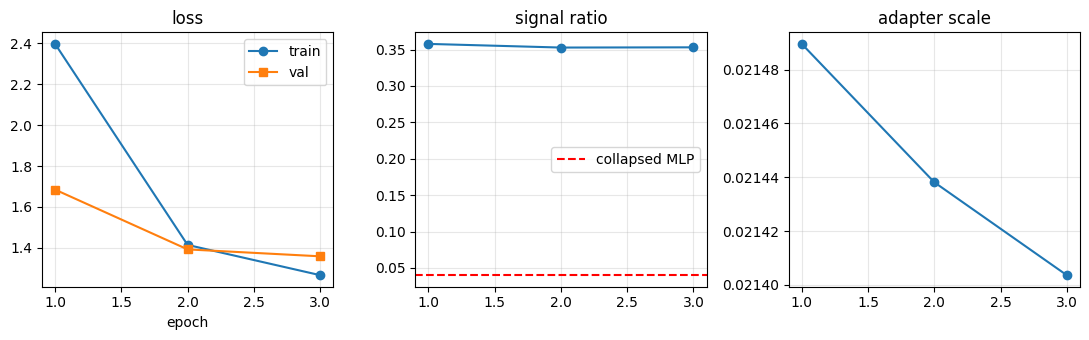

In [ ]:
e = [h["epoch"] for h in hist]
plt.figure(figsize=(11, 3.5))
plt.subplot(1, 3, 1)
plt.plot(e, [h["train"] for h in hist], "o-", label="train")
plt.plot(e, [h["val"] for h in hist], "s-", label="val")
plt.xlabel("epoch"); plt.legend(); plt.grid(alpha=.3); plt.title("loss")
plt.subplot(1, 3, 2)
plt.plot(e, [h["signal"] for h in hist], "o-")
plt.axhline(0.04, c="r", ls="--", label="collapsed MLP")
plt.legend(); plt.grid(alpha=.3); plt.title("signal ratio")
plt.subplot(1, 3, 3)
plt.plot(e, [h["scale"] for h in hist], "o-"); plt.grid(alpha=.3)
plt.title("adapter scale")
plt.tight_layout(); plt.savefig(f"{OUT_ROOT}/run_{RUN_NAME}/curves.png", dpi=140)
plt.show()

## 6. Generate on the test split



In [ ]:
@torch.no_grad()
def generate(item, sampled=True, max_new=200):
    px, _, _ = preprocess(item["image"])
    vis = adapter(encode_image(vision, px[None]).float())
    ids = tok(SYSTEM + INSTR_FINDGEN, return_tensors="pt")["input_ids"].to(device)
    emb = llm.get_input_embeddings()(ids)
    inp = torch.cat([vis.to(emb.dtype), emb], dim=1)
    kw = dict(inputs_embeds=inp,
              attention_mask=torch.ones(inp.shape[:2], dtype=torch.long,
                                        device=device),
              max_new_tokens=max_new, pad_token_id=tok.eos_token_id)
    kw.update(dict(do_sample=True, top_p=0.9, temperature=0.7,
                   repetition_penalty=1.15) if sampled
              else dict(do_sample=False))
    out = llm.generate(**kw)
    txt = tok.decode(out[0], skip_special_tokens=True)
    for t in ["<obj>", "</obj>", "<box>", "</box>"]:
        txt = txt.replace(t, " ")
    return " ".join(txt.split())


llm.eval(); adapter.eval()
test_items = [ds_iu[i] for i in splits["test"]]
refs = [(it.get("text") or "").strip() for it in test_items]

gen = {}
for mode in ["greedy", "sampled"]:
    hs, t0 = [], time.time()
    for k, it in enumerate(test_items):
        hs.append(generate(it, sampled=(mode == "sampled")))
        if (k+1) % 50 == 0:
            print(f"  {mode} {k+1}/{len(test_items)} | {(time.time()-t0)/60:.1f}m")
    gen[mode] = hs
    print(f"{mode} done\n  example: {hs[0][:110]}")

  greedy 50/265 | 4.4m
  greedy 100/265 | 8.7m
  greedy 150/265 | 12.8m
  greedy 200/265 | 16.9m
  greedy 250/265 | 21.1m
greedy done
  example: the heart is normal in size the mediastinum is unremarkable there is no focal airspace opacity pleural effusio
  sampled 50/265 | 4.4m
  sampled 100/265 | 9.3m
  sampled 150/265 | 13.8m
  sampled 200/265 | 18.2m
  sampled 250/265 | 22.4m
sampled done
  example: heart size is within normal limits no focal airspace consolidation pleural effusion or pneumothorax no acute b


## 7. Metrics



In [ ]:
import nltk
for p in ["wordnet", "punkt", "punkt_tab", "omw-1.4"]:
    nltk.download(p, quiet=True)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
from collections import Counter


def nlg_metrics(hyps, refs):
    h = [x.lower().split() for x in hyps]
    r = [[x.lower().split()] for x in refs]
    sm = SmoothingFunction().method1
    out = {f"BLEU-{n}": corpus_bleu(r, h, weights=tuple([1.0/n]*n),
                                    smoothing_function=sm) for n in range(1, 5)}
    rs = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
    out["ROUGE-L"] = float(np.mean([rs.score(a, b)["rougeL"].fmeasure
                                    for a, b in zip(refs, hyps)]))
    out["METEOR"] = float(np.mean([meteor_score([a[0]], b)
                                   for a, b in zip(r, h)]))
    try:
        from bert_score import score as bsc
        _, _, f1 = bsc(hyps, refs, lang="en", verbose=False,
                       model_type="distilbert-base-uncased")
        out["BERTScore-F1"] = float(f1.mean())
    except Exception as ex:
        print("  BERTScore skipped:", str(ex)[:70])
    try:
        from f1chexbert import F1CheXbert
        cx = F1CheXbert(device=device)
        _, _, cr, _ = cx(hyps=hyps, refs=refs)
        out["CheXbert_micro_F1"] = cr["micro avg"]["f1-score"]
        out["CheXbert_macro_F1"] = cr["macro avg"]["f1-score"]
    except Exception as ex:
        print("  CheXbert skipped:", str(ex)[:70])
    try:
        from radgraph import F1RadGraph
        s, _, _, _ = F1RadGraph(reward_level="partial")(hyps=hyps, refs=refs)
        out["RadGraph_F1"] = float(s)
    except Exception as ex:
        print("  RadGraph skipped:", str(ex)[:70])
    return out


def diversity(reports):
    n = len(reports)
    norm = [" ".join(x.lower().split()) for x in reports]
    c = Counter(norm)
    return {"uniqueness_%": 100*len(set(norm))/n,
            "most_common_%": 100*c.most_common(1)[0][1]/n,
            "distinct_1": len({w for x in norm for w in x.split()}),
            "distinct_2": len({tuple(x.split()[i:i+2]) for x in norm
                               for i in range(max(0, len(x.split())-1))})}


tr_reports = [" ".join((ds_iu[i].get("text") or "").lower().split())
              for i in splits["train"]]
const, cnt = Counter(tr_reports).most_common(1)[0]
print(f"constant baseline: {cnt}/{len(tr_reports)} "
      f"({100*cnt/len(tr_reports):.1f}% of training reports)")
print(f'  "{const[:110]}..."')

results = {}
for mode in ["greedy", "sampled"]:
    print(f"\ncomputing {mode}...")
    results[mode] = {"nlg": nlg_metrics(gen[mode], refs),
                     "div": diversity(gen[mode])}
print("\ncomputing constant baseline...")
results["constant"] = {"nlg": nlg_metrics([const]*len(refs), refs),
                       "div": diversity([const]*len(refs))}

constant baseline: 39/1964 (2.0% of training reports)
  "heart size normal lungs are clear are normal no pneumonia effusions edema pneumothorax adenopathy nodules or m..."

computing greedy...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  CheXbert skipped: [Errno 2] No such file or directory: '/root/.cache/chexbert/chexbert.p
Using device: cuda:0
model_type not provided, defaulting to radgraph-xl
  RadGraph skipped: BertTokenizer has no attribute encode_plus

computing constant baseline...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  CheXbert skipped: [Errno 2] No such file or directory: '/root/.cache/chexbert/chexbert.p
Using device: cuda:0
model_type not provided, defaulting to radgraph-xl
  RadGraph skipped: BertTokenizer has no attribute encode_plus


### 7.1 Results table

In [ ]:
keys = ["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4", "ROUGE-L", "METEOR",
        "BERTScore-F1", "CheXbert_micro_F1", "CheXbert_macro_F1", "RadGraph_F1"]

print(f"### IU X-ray — {RUN_NAME}, n={len(refs)} test images\n")
print("| Metric | Greedy | Sampled | Constant |")
print("|---|---|---|---|")
for k in keys:
    row = [results[m]["nlg"].get(k) for m in ["greedy", "sampled", "constant"]]
    if all(v is None for v in row): continue
    print("| " + k + " | " +
          " | ".join(f"{v*100:.2f}" if v is not None else "—" for v in row) + " |")

print("\n| Diversity | Greedy | Sampled | Reference |")
print("|---|---|---|---|")
ref_div = diversity(refs)
for k in ["uniqueness_%", "most_common_%", "distinct_1", "distinct_2"]:
    print(f"| {k} | {results['greedy']['div'][k]:.1f} | "
          f"{results['sampled']['div'][k]:.1f} | {ref_div[k]:.1f} |")

json.dump({"run": RUN_NAME, "n_test": len(refs), "results": results,
           "reference_diversity": ref_div, "history": hist},
          open(f"{OUT_ROOT}/run_{RUN_NAME}/nlg_results.json", "w"),
          indent=2, default=str)

print("\nPRIOR RUN (collapsed MLP adapter):")
print("  greedy  ROUGE-L 31.64 | uniqueness  0.75% | distinct-1  22")
print("  sampled ROUGE-L 28.57 | uniqueness 79.10% | distinct-1 223")
print("MAIRA-2 held-out IU: ROUGE-L 27.4 | BLEU-4 11.7")

### IU X-ray — A_iu_unified, n=265 test images

| Metric | Greedy | Sampled | Constant |
|---|---|---|---|
| BLEU-1 | 32.73 | 35.48 | 18.86 |
| BLEU-2 | 19.20 | 20.99 | 8.50 |
| BLEU-3 | 12.26 | 13.60 | 4.20 |
| BLEU-4 | 8.05 | 8.91 | 1.30 |
| ROUGE-L | 30.96 | 29.59 | 25.18 |
| METEOR | 29.94 | 31.27 | 18.24 |
| BERTScore-F1 | 86.83 | 86.04 | 84.36 |

| Diversity | Greedy | Sampled | Reference |
|---|---|---|---|
| uniqueness_% | 5.7 | 81.5 | 68.3 |
| most_common_% | 66.4 | 4.9 | 8.3 |
| distinct_1 | 51.0 | 244.0 | 533.0 |
| distinct_2 | 90.0 | 706.0 | 1908.0 |

PRIOR RUN (collapsed MLP adapter):
  greedy  ROUGE-L 31.64 | uniqueness  0.75% | distinct-1  22
  sampled ROUGE-L 28.57 | uniqueness 79.10% | distinct-1 223
MAIRA-2 held-out IU: ROUGE-L 27.4 | BLEU-4 11.7


In [ ]:
keys = [
    "BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4",
    "ROUGE-L", "METEOR", "BERTScore-F1",
    "CheXbert_micro_F1", "CheXbert_macro_F1", "RadGraph_F1"
]

print(f"### IU X-ray — {RUN_NAME}, n={len(refs)} test images\n")

# ---------------------------------------------------------
# NLG METRICS
# ---------------------------------------------------------
print("| Metric | Greedy | Sampled | Constant |")
print("|---|---|---|---|")

for k in keys:
    row = [
        results[m]["nlg"].get(k)
        for m in ["greedy", "sampled", "constant"]
    ]

    if all(v is None for v in row):
        continue

    print(
        "| " + k + " | " +
        " | ".join(
            f"{v*100:.2f}" if v is not None else "—"
            for v in row
        ) +
        " |"
    )


# ---------------------------------------------------------
# DIVERSITY METRICS
# ---------------------------------------------------------
print("\n| Diversity | Greedy | Sampled | Constant | Reference |")
print("|---|---|---|---|---|")

# Reference diversity
ref_div = diversity(refs)

# Constant-report diversity
# IMPORTANT:
# Replace "reports" below with the actual key containing
# the generated constant reports if your results dictionary
# uses a different name.
constant_reports = results["constant"]["reports"]

constant_div = diversity(constant_reports)

for k in [
    "uniqueness_%",
    "most_common_%",
    "distinct_1",
    "distinct_2"
]:
    print(
        f"| {k} | "
        f"{results['greedy']['div'][k]:.1f} | "
        f"{results['sampled']['div'][k]:.1f} | "
        f"{constant_div[k]:.1f} | "
        f"{ref_div[k]:.1f} |"
    )


# ---------------------------------------------------------
# SAVE RESULTS
# ---------------------------------------------------------
json.dump(
    {
        "run": RUN_NAME,
        "n_test": len(refs),
        "results": results,
        "reference_diversity": ref_div,
        "constant_diversity": constant_div,
        "history": hist
    },
    open(f"{OUT_ROOT}/run_{RUN_NAME}/nlg_results_new.json", "w"),
    indent=2,
    default=str
)


# ---------------------------------------------------------
# PREVIOUS RUN
# ---------------------------------------------------------
print("\nPRIOR RUN (collapsed MLP adapter):")
print("  greedy  ROUGE-L 31.64 | uniqueness  0.75% | distinct-1  22")
print("  sampled ROUGE-L 28.57 | uniqueness 79.10% | distinct-1 223")

print("MAIRA-2 held-out IU: ROUGE-L 27.4 | BLEU-4 11.7")

### 7.2 Qualitative

In [ ]:
for i in range(6):
    print("=" * 72)
    print("REF    :", refs[i][:150])
    print("GREEDY :", gen["greedy"][i][:150])
    print("SAMPLED:", gen["sampled"][i][:150])

REF    : the cardiac silhouette and mediastinum size are within normal limits there is no pulmonary edema there is no focal consolidation there are no  of a la
GREEDY : the heart is normal in size the mediastinum is unremarkable there is no focal airspace opacity pleural effusion or pneumothorax
SAMPLED: heart size is within normal limits no focal airspace consolidation pleural effusion or pneumothorax no acute bony abnormality
REF    : cardiac and mediastinal contours are within normal limits the lungs are clear acromioclavicular arthritis is present  severe
GREEDY : the heart is normal in size the mediastinum is unremarkable there is no focal air space opacity pleural effusion or pneumothorax
SAMPLED: the lungs are clear the heart and pulmonary appear normal no pleural effusion or pneumothorax is seen bony structures are intact
REF    : normal heart size clear hyperaerated lungs no pneumothorax no pleural effusion  substernal density may be related to a pectus deformity
GREEDY : the 